<a href="https://colab.research.google.com/github/Banj2/Banj2.github.io/blob/main/Amazon_Food_Review.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

#Amazon Food Review

In [18]:
import os
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn import linear_model, naive_bayes, ensemble ,tree, svm ,model_selection,preprocessing,\
 feature_extraction, metrics, base, pipeline
from joblib import dump,load
import PIL
from IPython.display import display
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
import seaborn as sns
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [19]:
df = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Files/AmazonFineFoods3k.csv')
display(df)

,565455,B002GKEK7G,A2BOPOKO6HKS3E,Stacey Walker,0,0.1,5,1317945600,My daily pick-me-up,I LOVE Click! My favorite protein drink by far. I add a little sugar-free caramel coffee syrup and a few drops coconut extract. Tastes just like a Samoa.
0,565456,B002GKEK7G,A1RJXXXKCCBRW1,curlymeg,0,0,4,1316304000,great drink,This is a nice drink when I have my chocolate ...
1,565457,B002GKEK7G,A18HMM4NUF4CJA,Kathy Little,0,0,5,1315612800,"Best tasting, hands down.",I have been drinking Click for almost two year...
2,565458,B002GKEK7G,A3TM73X9E4X44C,Lovingliving 990,0,0,5,1314835200,AWESOME PRODUCT,This is such a wonderful product. There is no...
3,565459,B002GKEK7G,A1N0A7NKLEZHIK,Chris S.,0,0,5,1314144000,Click starts my day!,Click is my protein drink every single morning...
4,565460,B002GKEK7G,A2AQL11U5EGHQE,violet412,0,0,5,1312329600,Addicted to this stuff. It is awesome.,This is my coffee and protein with great flavo...
...,...,...,...,...,...,...,...,...,...,...
2994,568450,B001EO7N10,A28KG5XORO54AY,Lettie D. Carter,0,0,5,1299628800,Will not do without,Great for sesame chicken..this is a good if no...
2995,568451,B003S1WTCU,A3I8AFVPEE8KI5,R. Sawyer,0,0,2,1331251200,disappointed,I'm disappointed with the flavor. The chocolat...
2996,568452,B004I613EE,A121AA1GQV751Z,"pksd ""pk_007""",2,2,5,1329782400,Perfect for our maltipoo,"These stars are small, so you can give 10-15 o..."
2997,568453,B004I613EE,A3IBEVCTXKNOH,"Kathy A. Welch ""katwel""",1,1,5,1331596800,Favorite Training and reward treat,These are the BEST treats for training and rew...


In [20]:
df.columns=['Amazon ID','Product ID','User ID','Username','No. of Ppl Useful','Ppl Not useful','rating 1-5','datetime','Review', 'Full Review']
display(df)

,Amazon ID,Product ID,User ID,Username,No. of Ppl Useful,Ppl Not useful,rating 1-5,datetime,Review,Full Review
0,565456,B002GKEK7G,A1RJXXXKCCBRW1,curlymeg,0,0,4,1316304000,great drink,This is a nice drink when I have my chocolate ...
1,565457,B002GKEK7G,A18HMM4NUF4CJA,Kathy Little,0,0,5,1315612800,"Best tasting, hands down.",I have been drinking Click for almost two year...
2,565458,B002GKEK7G,A3TM73X9E4X44C,Lovingliving 990,0,0,5,1314835200,AWESOME PRODUCT,This is such a wonderful product. There is no...
3,565459,B002GKEK7G,A1N0A7NKLEZHIK,Chris S.,0,0,5,1314144000,Click starts my day!,Click is my protein drink every single morning...
4,565460,B002GKEK7G,A2AQL11U5EGHQE,violet412,0,0,5,1312329600,Addicted to this stuff. It is awesome.,This is my coffee and protein with great flavo...
...,...,...,...,...,...,...,...,...,...,...
2994,568450,B001EO7N10,A28KG5XORO54AY,Lettie D. Carter,0,0,5,1299628800,Will not do without,Great for sesame chicken..this is a good if no...
2995,568451,B003S1WTCU,A3I8AFVPEE8KI5,R. Sawyer,0,0,2,1331251200,disappointed,I'm disappointed with the flavor. The chocolat...
2996,568452,B004I613EE,A121AA1GQV751Z,"pksd ""pk_007""",2,2,5,1329782400,Perfect for our maltipoo,"These stars are small, so you can give 10-15 o..."
2997,568453,B004I613EE,A3IBEVCTXKNOH,"Kathy A. Welch ""katwel""",1,1,5,1331596800,Favorite Training and reward treat,These are the BEST treats for training and rew...


In [21]:
df.isna().sum()


,0
Amazon ID,0
Product ID,0
User ID,0
Username,0
No. of Ppl Useful,0
Ppl Not useful,0
rating 1-5,0
datetime,0
Review,0
Full Review,0


In [22]:
df.drop(['Product ID', 'Amazon ID','User ID','datetime','Review'], axis = 1, inplace = True)
display(df)

,Username,No. of Ppl Useful,Ppl Not useful,rating 1-5,Full Review
0,curlymeg,0,0,4,This is a nice drink when I have my chocolate ...
1,Kathy Little,0,0,5,I have been drinking Click for almost two year...
2,Lovingliving 990,0,0,5,This is such a wonderful product. There is no...
3,Chris S.,0,0,5,Click is my protein drink every single morning...
4,violet412,0,0,5,This is my coffee and protein with great flavo...
...,...,...,...,...,...
2994,Lettie D. Carter,0,0,5,Great for sesame chicken..this is a good if no...
2995,R. Sawyer,0,0,2,I'm disappointed with the flavor. The chocolat...
2996,"pksd ""pk_007""",2,2,5,"These stars are small, so you can give 10-15 o..."
2997,"Kathy A. Welch ""katwel""",1,1,5,These are the BEST treats for training and rew...


In [23]:
print(f"number of duplicates: {np.sum(df.duplicated())}")

df.drop_duplicates(inplace=True)
print(f"number of duplicates after: {np.sum(df.duplicated())}")

number of duplicates: 2
number of duplicates after: 0


In [24]:
labels_counts = df['rating 1-5'].value_counts()
labels_counts

,count
rating 1-5,
5,1916
4,398
1,286
3,224
2,173


In [25]:
df['info'] = df['Username']+" "+ df['Full Review']
print(df['info'])

0       curlymeg This is a nice drink when I have my c...
1       Kathy Little I have been drinking Click for al...
2       Lovingliving 990 This is such a wonderful prod...
3       Chris S. Click is my protein drink every singl...
4       violet412 This is my coffee and protein with g...
                              ...                        
2994    Lettie D. Carter Great for sesame chicken..thi...
2995    R. Sawyer I'm disappointed with the flavor. Th...
2996    pksd "pk_007" These stars are small, so you ca...
2997    Kathy A. Welch "katwel" These are the BEST tre...
2998    srfell17 I am very satisfied ,product is as ad...
Name: info, Length: 2997, dtype: object


In [26]:
x = df['info'].values
y = df['rating 1-5'].values

print(x.shape,y.shape)

(2997,) (2997,)


In [27]:
vectorizer = feature_extraction.text.CountVectorizer()

In [28]:
x = vectorizer.fit_transform(x.reshape(-1))# .reshape only converts the x into a 1d dataset
print("Number of features: ",len(vectorizer.get_feature_names_out()))

Number of features:  13504


In [29]:
x_train, x_test, y_train, y_test = model_selection.train_test_split(x,y, test_size= 0.2, random_state=22, stratify=y)

In [30]:
nb = naive_bayes.MultinomialNB()
knn = KNeighborsClassifier(n_neighbors=5)

models = [nb,knn]
scores = []

In [36]:
def evaluate(model):
  cross_val_scores = model_selection.cross_val_score(base.clone(model),x_train, y_train, cv = 5)
  print(f"\nCross Validation Scores for model {model}: ")
  print(cross_val_scores, cross_val_scores.mean())
  scores.append(cross_val_scores.mean())
  model.fit(x_train, y_train)
  y_pred = model.predict(x_test)
  accuracy = accuracy_score(y_test, y_pred)
  print('Accuracy: ', accuracy)
  print('Classification report \n', classification_report(y_test,y_pred))
  print('Confusion Matrix\n', confusion_matrix(y_test,y_pred))
  conf_matrix = confusion_matrix(y_test,y_pred)
  plt.figure(figsize=(8,6))
  sns.heatmap(conf_matrix, annot=True, fmt = 'd', cmap='Blues', xticklabels=["1 Star", "2 Star","3 Star","4 Star","5 Star"],yticklabels=["1 Star", "2 Star","3 Star","4 Star","5 Star"])
  ;
  plt.xlabel('Predicted')
  plt.ylabel('Actual')
  plt.title('Confusion Matrix')
  plt.show()


Cross Validation Scores for model MultinomialNB(): 
[0.64166667 0.63958333 0.64300626 0.64718163 0.6263048 ] 0.6395485386221293
Accuracy:  0.6333333333333333
Classification report 
               precision    recall  f1-score   support

           1       0.62      0.14      0.23        57
           2       0.00      0.00      0.00        35
           3       0.00      0.00      0.00        45
           4       0.16      0.05      0.08        80
           5       0.66      0.96      0.78       383

    accuracy                           0.63       600
   macro avg       0.29      0.23      0.22       600
weighted avg       0.50      0.63      0.53       600

Confusion Matrix
 [[  8   0   0   4  45]
 [  3   0   1   1  30]
 [  0   0   0   2  43]
 [  1   0   1   4  74]
 [  1   0   0  14 368]]


/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


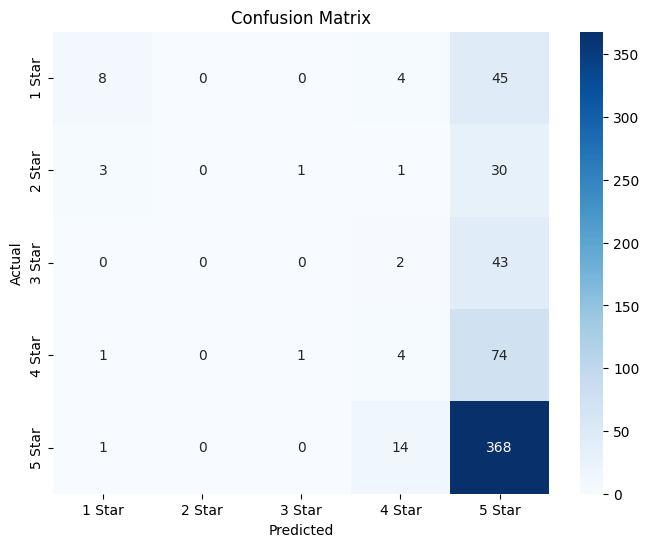


Cross Validation Scores for model KNeighborsClassifier(): 
[0.62291667 0.61875    0.63048017 0.60542797 0.60751566] 0.617018093249826
Accuracy:  0.615
Classification report 
               precision    recall  f1-score   support

           1       0.29      0.09      0.14        57
           2       0.15      0.06      0.08        35
           3       0.14      0.07      0.09        45
           4       0.27      0.07      0.12        80
           5       0.67      0.92      0.78       383

    accuracy                           0.61       600
   macro avg       0.31      0.24      0.24       600
weighted avg       0.51      0.61      0.54       600

Confusion Matrix
 [[  5   1   3   0  48]
 [  1   2   3   1  28]
 [  1   1   3   4  36]
 [  3   3   6   6  62]
 [  7   6   6  11 353]]


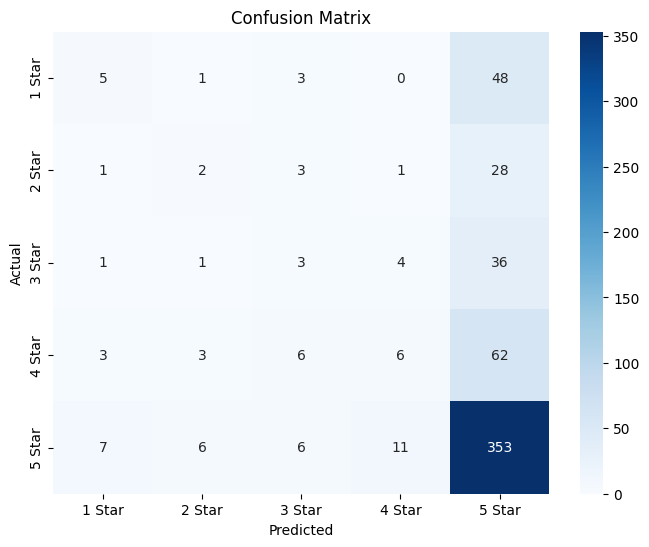

In [37]:
for model in models:
  evaluate(model)